In [2]:
import numpy as np
import pandas as pd
import duckdb
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text

In [3]:
# Connect to a database file 
con = duckdb.connect('../aav_manufacturing.db') 

In [4]:
query = """SELECT * FROM telemetry_aligned """
df_aligned = con.execute(query).df()

# Calculate instantaneous rates in the aligned dataframe
df_aligned = df_aligned.sort_values(['Batch_ID', 'Hour'])
df_aligned['dt'] = df_aligned.groupby('Batch_ID')['Hour'].diff()

# Growth Rate (mu): (ΔVCD / VCD) / Δt
df_aligned['Growth_Rate'] = df_aligned.groupby('Batch_ID')['VCD'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Production Rate (qp): ΔP / (VCD * Δt)
df_aligned['Production_Rate'] = df_aligned.groupby('Batch_ID')['Product'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Consumption Rate (qg): ΔG / (VCD * Δt)
df_aligned['Consumption_Rate'] = df_aligned.groupby('Batch_ID')['Glucose'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Register with DuckDB
con.register('telemetry_aligned', df_aligned)

In [5]:
query = """
SELECT 
    o.Batch_ID, 
    o.Status, 
    o.Full_Titer, 
    MAX(t.Ammonia) AS Max_Ammonia,
    MAX(t.Lactate) AS Max_Lactate,
    MIN(t.pH) AS Min_pH,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Growth_Rate END) AS Avg_Growth_Rate,
    AVG(CASE WHEN t.Hour >= 72 THEN t.Production_Rate END) AS Avg_Prod_Rate,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Consumption_Rate END) AS Avg_Gluc_Cons
FROM outcomes o
JOIN telemetry_aligned t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Status, o.Full_Titer
"""

df_pca_final = con.execute(query).df()
con.close()

In [6]:
# Define features for the model
feature_cols = ['Max_Ammonia', 'Max_Lactate', 'Min_pH', 
                'Avg_Growth_Rate', 'Avg_Prod_Rate', 'Avg_Gluc_Cons']

# Handle missing values (if any rates couldn't be calculated)
df_pca_final = df_pca_final.dropna(subset=feature_cols)

# Scale the data (Mandatory for PCA)
scaler = StandardScaler()
X = scaler.fit_transform(df_pca_final[feature_cols])

In [7]:
# Run PCA
pca = PCA(n_components=5)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2','PC3','PC4','PC5'])
df_pca_plot['Status'] = df_pca_final['Status'].values

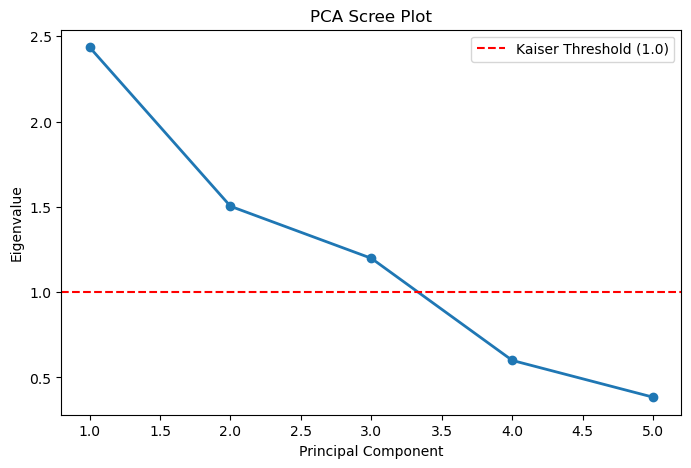

In [8]:
# Calculate Eigenvalues
eigenvalues = pca.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Threshold (1.0)')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

In [9]:
# Run PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca_plot['Status'] = df_pca_final['Status'].values

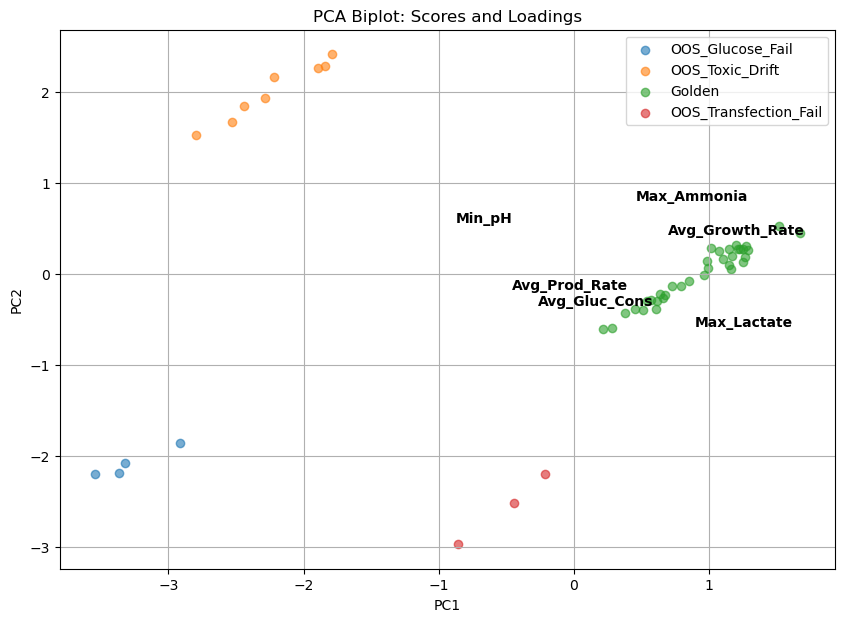

In [10]:
# Extract loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create Biplot
plt.figure(figsize=(10, 7))

# Plot the scores (the batches)
for status in df_pca_final['Status'].unique():
    mask = df_pca_final['Status'] == status
    plt.scatter(principal_components[mask, 0], principal_components[mask, 1], label=status, alpha=0.6)

texts = []
for i, feature in enumerate(feature_cols):
    texts.append(plt.text(loadings[i, 0], loadings[i, 1], feature, fontweight='bold'))

# This function iteratively moves text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))


plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot: Scores and Loadings')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

# Plot the loadings (the variables)
for i, feature in enumerate(feature_cols):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05)
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, color='g', ha='center', va='center')
